In [1]:
# Name-Lanke Payal Sambhaji
# Roll No-152 
#Div-B

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
#Load the dataset
df = pd.read_csv("marketing_campaign.csv", sep='\t')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
#Data Cleaning
df = df.drop(['ID','Dt_Customer','Z_CostContact','Z_Revenue'], axis=1)

print(df.isnull().sum())

# Fill missing income values
df['Income'] = df['Income'].fillna(df['Income'].mean())

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64


In [5]:
# Feature Engineering
# Total spending of customer
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

# Total children in household
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Total purchases
df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)
df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Total_Spending,Total_Children,Total_Purchases
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,0,0,0,0,0,0,1,1617,0,22
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,0,0,0,0,0,0,0,27,2,4
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,0,0,0,0,0,0,0,776,0,20
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,0,0,0,0,0,0,0,53,1,6
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,0,0,0,0,0,0,0,422,1,14


In [6]:
#Conversion of categorical variables
df = pd.get_dummies(df, drop_first=True)
print(df)

      Year_Birth   Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0           1957  58138.0        0         0       58       635         88   
1           1954  46344.0        1         1       38        11          1   
2           1965  71613.0        0         0       26       426         49   
3           1984  26646.0        1         0       26        11          4   
4           1981  58293.0        1         0       94       173         43   
...          ...      ...      ...       ...      ...       ...        ...   
2235        1967  61223.0        0         1       46       709         43   
2236        1946  64014.0        2         1       56       406          0   
2237        1981  56981.0        0         0       91       908         48   
2238        1956  69245.0        0         1        8       428         30   
2239        1954  52869.0        1         1       40        84          3   

      MntMeatProducts  MntFishProducts  MntSweetProducts  ...  

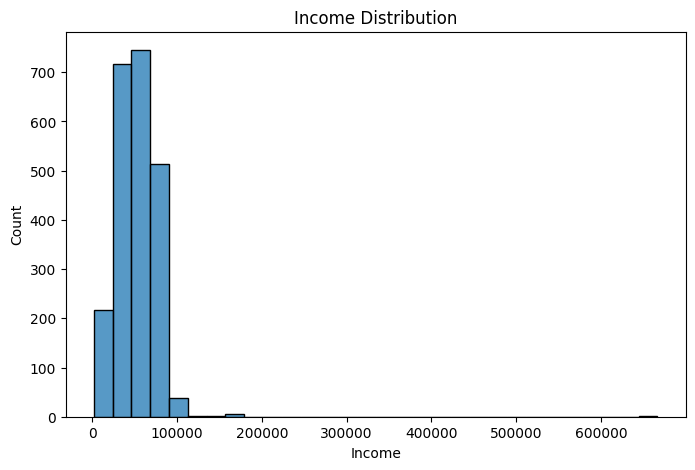

In [7]:
#Income Distribution Visualization
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=30)
plt.title("Income Distribution")
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3820\35324826.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_spending = df.groupby('Income_Group')['Total_Spending'].mean().reset_index()


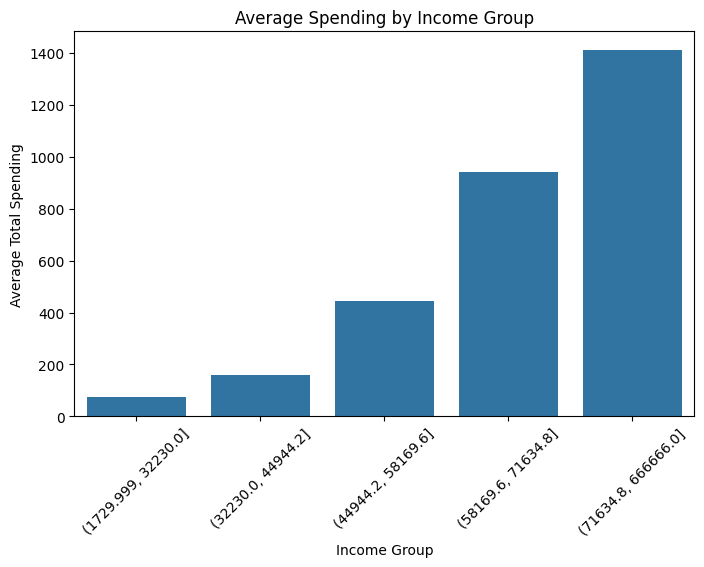

In [10]:
#Average Spending by income group
# Create income groups
df['Income_Group'] = pd.qcut(df['Income'], 5)

# Calculate average spending
income_spending = df.groupby('Income_Group')['Total_Spending'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x='Income_Group',
    y='Total_Spending',
    data=income_spending
)

plt.title("Average Spending by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Total Spending")

plt.xticks(rotation=45)
plt.show()

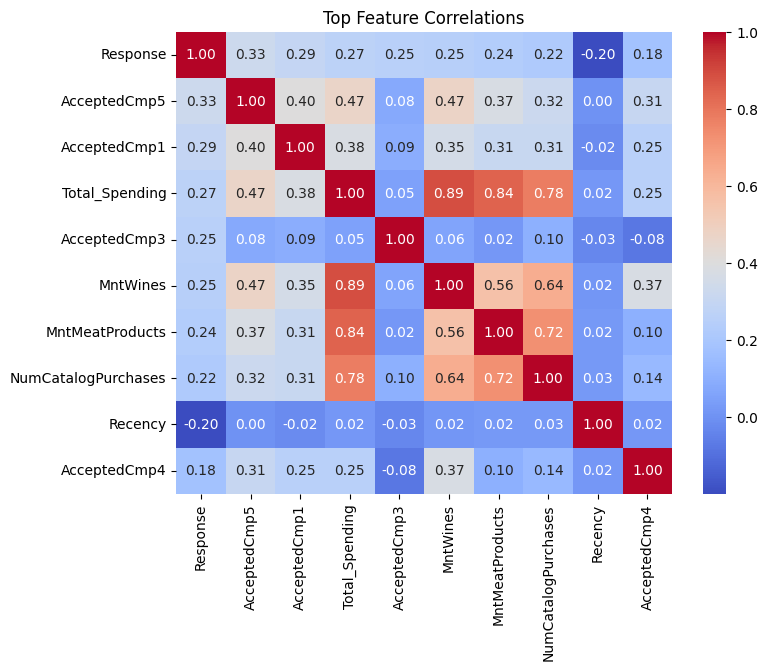

In [13]:
#Correlation Heatmap

corr_matrix = df.corr(numeric_only=True)

top_features = corr_matrix['Response'].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(8,6))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Top Feature Correlations")
plt.show()

In [12]:
#Train_Test Split
X = df.drop('Response', axis=1)
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1792, 37)
Testing Data: (448, 37)


In [15]:
#Standardization
X_numeric = X.select_dtypes(include=['number'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape after PCA:", X_train_pca.shape)

Shape after PCA: (1792, 10)


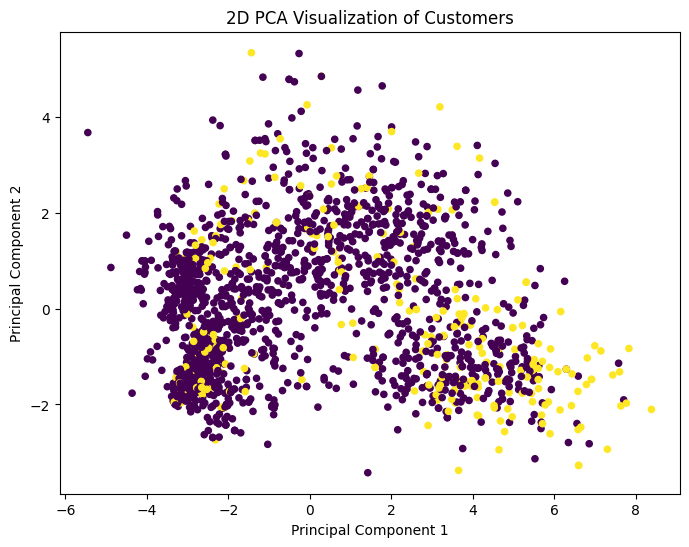

In [17]:
#PCA 2d Visualization
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=y_train,
    cmap="viridis",
    s=20
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization of Customers")

plt.show()

In [18]:
#t-SNE Dimensionality Reduction
X_tsne_input = X_train_scaled[:1000]
y_tsne = y_train[:1000]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_tsne = tsne.fit_transform(X_tsne_input)

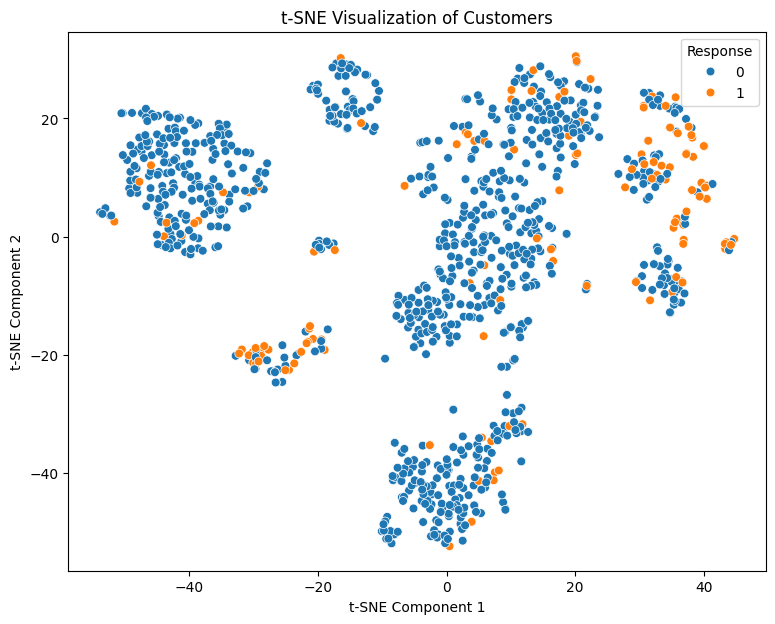

In [19]:
#t-SNE Visualization
plt.figure(figsize=(9,7))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=y_tsne,
    palette="tab10",
    s=40
)

plt.title("t-SNE Visualization of Customers")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(title="Response")

plt.show()

In [20]:
# Train Machine Learning Model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train_pca, y_train)

# Make predictions
y_pred = model.predict(X_test_pca)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8616071428571429


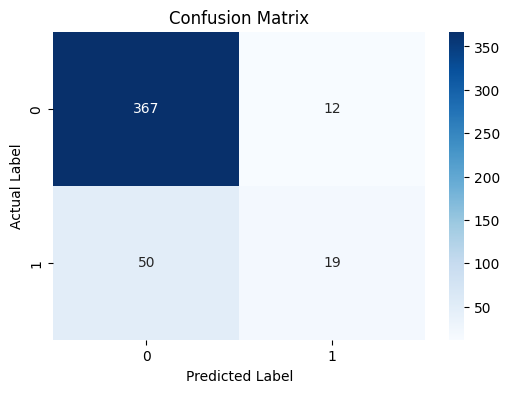

In [21]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [22]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       379
           1       0.61      0.28      0.38        69

    accuracy                           0.86       448
   macro avg       0.75      0.62      0.65       448
weighted avg       0.84      0.86      0.84       448

